<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/M%C3%89TODO_DE_COLOCACI%C3%93N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

Queremos resolver la ecuación:

d²u/ dx² + u = x

sujeta a las condiciones:

    u(0)= 0, u'(0)= 2

Analíticamente:

In [2]:
x = sp.symbols('x') #introducimos una variable
u = sp.Function('u') #esto es una función

In [37]:
x

x

In [41]:
ode = u(x).diff(x, x)+ u(x) - x
sp.dsolve(ode, u(x))


Eq(u(x), C1*sin(x) + C2*cos(x) + x)

In [43]:
sol = sp.dsolve(ode, ics={u(0): 0, sp.diff(u(x),x).subs(x,0): 2})

In [44]:
sol

Eq(u(x), x + sin(x))

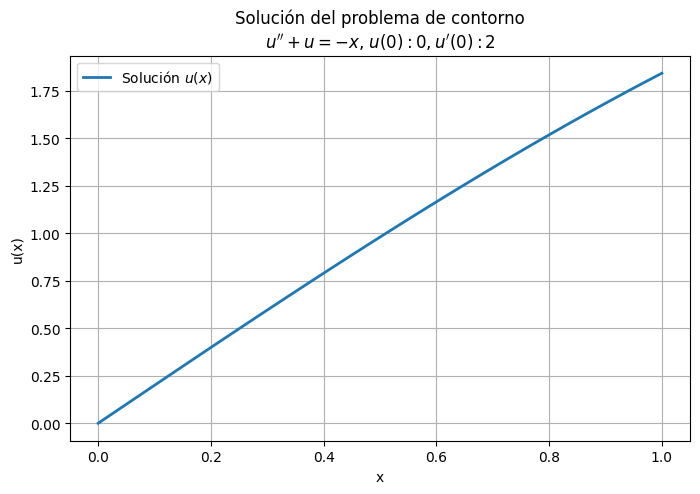

In [46]:
#
u_expr = sol.rhs


u_num = sp.lambdify(x, u_expr, "numpy")

#################
xx= np.linspace(0, 1, 100)
yy= u_num(xx)


plt.figure(figsize=(8,5))
plt.plot(xx, yy, label= "Solución $u(x)$", linewidth=2)
plt.title("Solución del problema de contorno\n$u'' + u = -x$, $u(0):0, u'(0):2$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.show()

Ahora con las funciones de prueba

In [52]:
a, b, c, d = sp.symbols('a b c d')
a = 0
b = 2

# Función de prueba u_n(x) que cumple u(0)=0, u'(0)=2

u_n = a + b*x + c*x**2 + d*x**3

In [53]:
u_n

c*x**2 + d*x**3 + 2*x

In [68]:

u_n_2 = sp.diff(u_n, x, 2)


F = u_n_2 + u_n - x

In [69]:
F

c*x**2 + d*x**3 + x + 2*(c + 3*d*x)

In [70]:
# Puntos de colocación

points = [sp.Rational(1,2), sp.Rational(1,1)]

In [71]:
points

[1/2, 1]

In [81]:
eqs = [sp. Eq(F.subs (x, p), 0)for p in points]

# Resolver para c y d

sol_1 = sp.solve(eqs,[c, d])

In [73]:
for eq in eqs:
  print(eq)

Eq(9*c/4 + 25*d/8 + 1/2, 0)
Eq(3*c + 7*d + 1, 0)


In [82]:
print ("Sistema de ecuaciones símbolicos: ")
for eq in eqs:
  sp.pprint(eq)

Sistema de ecuaciones símbolicos: 
9⋅c   25⋅d   1    
─── + ──── + ─ = 0
 4     8     2    
3⋅c + 7⋅d + 1 = 0


In [83]:
sol_1

{c: -1/17, d: -2/17}

In [84]:
# Sustituir en la función de prueba
u_approx = u_n.subs(sol_1)

In [85]:
u_approx

-2*x**3/17 - x**2/17 + 2*x

In [86]:
u_approx_fn = sp.lambdify(x, u_approx, "numpy")

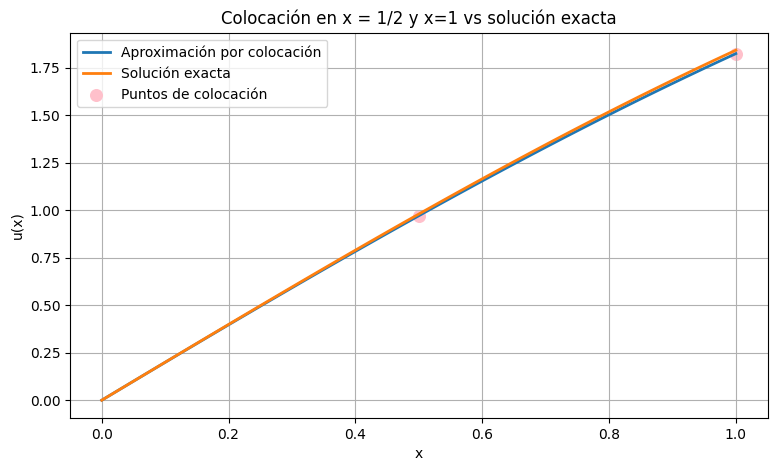

In [100]:
# Solución analítica y numérica
xx = np.linspace(0, 1, 100)

plt.figure(figsize=(9,5))
plt.plot(xx, u_approx_fn(xx), label= "Aproximación por colocación", linewidth=2)
plt.plot(xx, yy, label= "Solución exacta", linewidth=2)

# puntos de colocación
plt.scatter([0.5, 1], u_approx_fn(np.array([0.5, 1 ])), color="pink", s=70, label= "Puntos de colocación")
plt.title("Colocación en x = 1/2 y x=1 vs solución exacta")
plt. xlabel('x')
plt.ylabel('u(x)')
plt.grid(True)
plt.legend()
plt.show()

In [101]:
# Calculamos el error.
error = np.abs(yy - u_approx_fn(xx))
error_max = np.max(error)
print("Error máximo:", error_max)

Error máximo: 0.01794157304319066
